<a href="https://colab.research.google.com/github/Dilshan-Pasindu/Machine-Learning--Lab/blob/main/IT24101554_ML_Lab_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import seaborn as sns

df = sns.load_dataset("titanic")

In [2]:
print(df.shape)
print(df.info())
print(df.dtypes)

(891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
survived          int64
pclass            int64
sex             

In [3]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [4]:
# Count duplicate records
print("Number of duplicate records:", df.duplicated().sum())

Number of duplicate records: 107


In [5]:
# Remove duplicate records
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (784, 15)


In [6]:
missing = df.isnull().sum()

print("Features containing missing values:")
print(missing[missing > 0])

Features containing missing values:
age            106
embarked         2
deck           582
embark_town      2
dtype: int64


In [7]:
# Make a copy
df_clean = df.copy()

# Display missing values before imputation
print("Missing values BEFORE imputation:")
print(df_clean.isnull().sum())

# Numerical columns
numeric_columns = df_clean.select_dtypes(
    include=["int64", "float64"]
).columns

# Fill numerical missing values with median
for col in numeric_columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Categorical columns
categorical_columns = df_clean.select_dtypes(
    include=["object", "category", "bool"]
).columns

# Fill categorical missing values with mode
for col in categorical_columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(
            df_clean[col].mode()[0]
        )

# Display missing values after imputation
print("\nMissing values AFTER imputation:")
print(df_clean.isnull().sum())

Missing values BEFORE imputation:
survived         0
pclass           0
sex              0
age            106
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           582
embark_town      2
alive            0
alone            0
dtype: int64

Missing values AFTER imputation:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


In [8]:
df_encoded = df_clean.copy()

# Binary encoding
df_encoded["sex"] = df_encoded["sex"].map({
    "male": 0,
    "female": 1
})

df_encoded["alive"] = df_encoded["alive"].map({
    "no": 0,
    "yes": 1
})

df_encoded["adult_male"] = df_encoded["adult_male"].astype(int)

df_encoded["alone"] = df_encoded["alone"].astype(int)

print(df_encoded.head())

   survived  pclass  sex   age  sibsp  parch     fare embarked  class    who  \
0         0       3    0  22.0      1      0   7.2500        S  Third    man   
1         1       1    1  38.0      1      0  71.2833        C  First  woman   
2         1       3    1  26.0      0      0   7.9250        S  Third  woman   
3         1       1    1  35.0      1      0  53.1000        S  First  woman   
4         0       3    0  35.0      0      0   8.0500        S  Third    man   

   adult_male deck  embark_town  alive  alone  
0           1    C  Southampton      0      0  
1           0    C    Cherbourg      1      0  
2           0    C  Southampton      1      1  
3           0    C  Southampton      1      0  
4           1    C  Southampton      0      1  


In [9]:
import pandas as pd

df_onehot = pd.get_dummies(
    df_clean,
    columns=["embarked", "embark_town", "who", "deck"],
    drop_first=False
)

print(df_onehot.head())

   survived  pclass     sex   age  sibsp  parch     fare  class  adult_male  \
0         0       3    male  22.0      1      0   7.2500  Third        True   
1         1       1  female  38.0      1      0  71.2833  First       False   
2         1       3  female  26.0      0      0   7.9250  Third       False   
3         1       1  female  35.0      1      0  53.1000  First       False   
4         0       3    male  35.0      0      0   8.0500  Third        True   

  alive  ...  who_child  who_man  who_woman  deck_A  deck_B  deck_C  deck_D  \
0    no  ...      False     True      False   False   False    True   False   
1   yes  ...      False    False       True   False   False    True   False   
2   yes  ...      False    False       True   False   False    True   False   
3   yes  ...      False    False       True   False   False    True   False   
4    no  ...      False     True      False   False   False    True   False   

   deck_E  deck_F  deck_G  
0   False   False   Fa

In [10]:
# Display only the newly created one-hot encoded columns

encoded_columns = [
    col for col in df_onehot.columns
    if col.startswith("embarked_")
    or col.startswith("embark_town_")
    or col.startswith("who_")
    or col.startswith("deck_")
]

print("\nOne-Hot Encoded Features:")
print(df_onehot[encoded_columns].head())


One-Hot Encoded Features:
   embarked_C  embarked_Q  embarked_S  embark_town_Cherbourg  \
0       False       False        True                  False   
1        True       False       False                   True   
2       False       False        True                  False   
3       False       False        True                  False   
4       False       False        True                  False   

   embark_town_Queenstown  embark_town_Southampton  who_child  who_man  \
0                   False                     True      False     True   
1                   False                    False      False    False   
2                   False                     True      False    False   
3                   False                     True      False    False   
4                   False                     True      False     True   

   who_woman  deck_A  deck_B  deck_C  deck_D  deck_E  deck_F  deck_G  
0      False   False   False    True   False   False   False   False  
1

In [11]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder(
    categories=[["First", "Second", "Third"]]
)

df_clean["class_encoded"] = ordinal_encoder.fit_transform(
    df_clean[["class"]]
)

print(df_clean[["class", "class_encoded"]].head())

   class  class_encoded
0  Third            2.0
1  First            0.0
2  Third            2.0
3  First            0.0
4  Third            2.0


In [12]:
from sklearn.preprocessing import StandardScaler

numeric_features = ["age", "sibsp", "parch", "fare"]

standard_scaler = StandardScaler()

standard_scaled = standard_scaler.fit_transform(
    df_clean[numeric_features]
)

standard_df = pd.DataFrame(
    standard_scaled,
    columns=numeric_features
)

print(standard_df.head())

        age     sibsp     parch      fare
0 -0.557360  0.484009 -0.497157 -0.526825
1  0.608298  0.484009 -0.497157  0.701587
2 -0.265945 -0.530599 -0.497157 -0.513876
3  0.389737  0.484009 -0.497157  0.352760
4  0.389737 -0.530599 -0.497157 -0.511478


In [13]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

minmax_scaled = minmax_scaler.fit_transform(
    df_clean[numeric_features]
)

minmax_df = pd.DataFrame(
    minmax_scaled,
    columns=numeric_features
)

print(minmax_df.head())

        age  sibsp  parch      fare
0  0.271174  0.125    0.0  0.014151
1  0.472229  0.125    0.0  0.139136
2  0.321438  0.000    0.0  0.015469
3  0.434531  0.125    0.0  0.103644
4  0.434531  0.000    0.0  0.015713


In [14]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()

robust_scaled = robust_scaler.fit_transform(
    df_clean[numeric_features]
)

robust_df = pd.DataFrame(
    robust_scaled,
    columns=numeric_features
)

print(robust_df.head())

        age  sibsp  parch      fare
0 -0.446429    1.0    0.0 -0.331935
1  0.696429    1.0    0.0  2.125276
2 -0.160714    0.0    0.0 -0.306032
3  0.482143    1.0    0.0  1.427511
4  0.482143    0.0    0.0 -0.301235


In [15]:
comparison = pd.DataFrame({
    "Original": df_clean["fare"].head(10).values,
    "StandardScaler": standard_df["fare"].head(10).values,
    "MinMaxScaler": minmax_df["fare"].head(10).values,
    "RobustScaler": robust_df["fare"].head(10).values
})

print(comparison)

   Original  StandardScaler  MinMaxScaler  RobustScaler
0    7.2500       -0.526825      0.014151     -0.331935
1   71.2833        0.701587      0.139136      2.125276
2    7.9250       -0.513876      0.015469     -0.306032
3   53.1000        0.352760      0.103644      1.427511
4    8.0500       -0.511478      0.015713     -0.301235
5    8.4583       -0.503645      0.016510     -0.285567
6   51.8625        0.329020      0.101229      1.380023
7   21.0750       -0.261607      0.041136      0.198585
8   11.1333       -0.452328      0.021731     -0.182917
9   30.0708       -0.089032      0.058694      0.543789


age      0.441779
sibsp    3.055367
parch    2.633002
fare     4.570768
dtype: float64


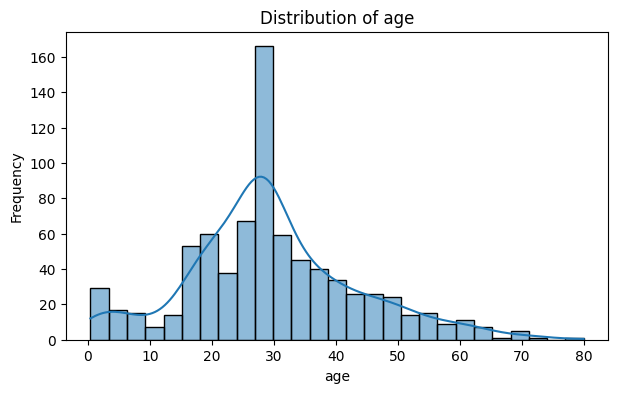

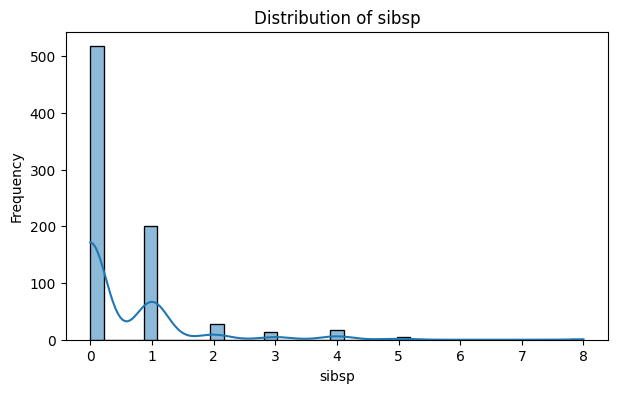

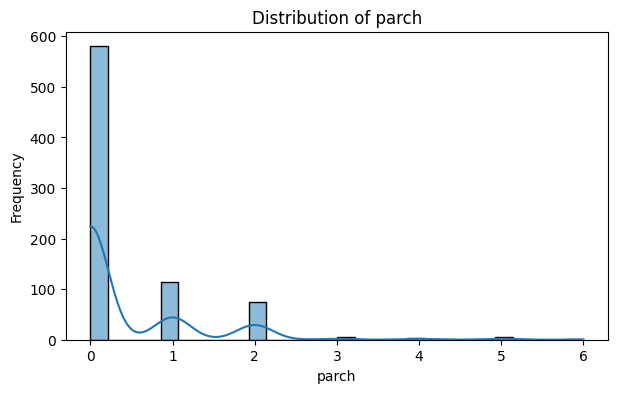

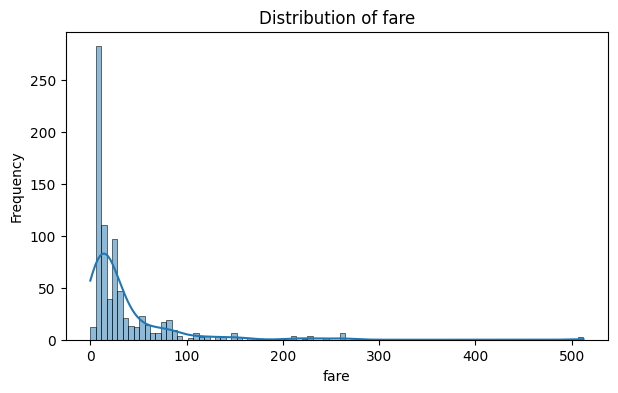

In [16]:
import matplotlib.pyplot as plt

numeric_features = ["age", "sibsp", "parch", "fare"]

# Calculate skewness
print(df_clean[numeric_features].skew())

for column in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(df_clean[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [17]:
import numpy as np
df_transformed = df_clean.copy()

# Apply log transformation
df_transformed["fare_log"] = np.log1p(
    df_transformed["fare"]
)

df_transformed["sibsp_log"] = np.log1p(
    df_transformed["sibsp"]
)

df_transformed["parch_log"] = np.log1p(
    df_transformed["parch"]
)

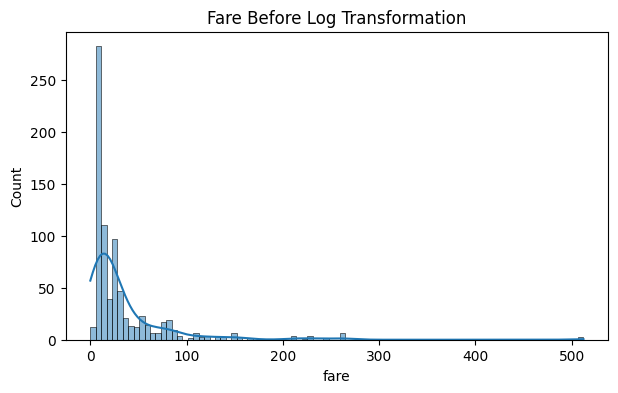

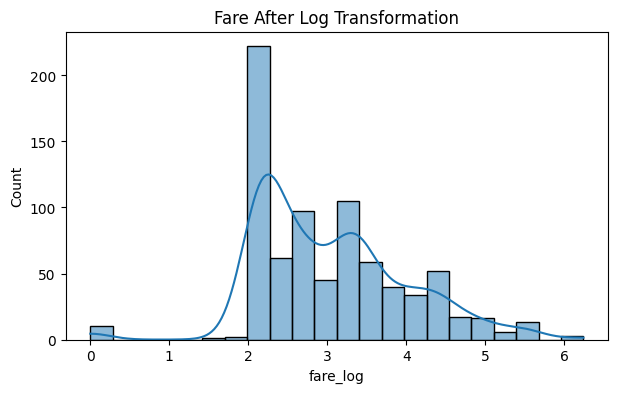

In [18]:
# Before transformation
plt.figure(figsize=(7, 4))
sns.histplot(df_clean["fare"], kde=True)
plt.title("Fare Before Log Transformation")
plt.show()

# After transformation
plt.figure(figsize=(7, 4))
sns.histplot(df_transformed["fare_log"], kde=True)
plt.title("Fare After Log Transformation")
plt.show()

In [19]:
# Feature Construction 1
df_clean["FamilySize"] = (
    df_clean["sibsp"] +
    df_clean["parch"] +
    1
)

print(df_clean[
    ["sibsp", "parch", "FamilySize"]
].head())

   sibsp  parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1


- Answer

FamilySize is useful because passengers travelling with family members may have different survival behaviour compared with passengers travelling alone. It combines sibsp and parch into one meaningful feature.

In [20]:
# Feature Construction 2
df_clean["FarePerPerson"] = (
    df_clean["fare"] /
    df_clean["FamilySize"]
)

print(df_clean[
    ["fare", "FamilySize", "FarePerPerson"]
].head())

      fare  FamilySize  FarePerPerson
0   7.2500           2        3.62500
1  71.2833           2       35.64165
2   7.9250           1        7.92500
3  53.1000           2       26.55000
4   8.0500           1        8.05000


- Answer

FarePerPerson can be useful because total fare can be affected by the size of the travelling group. Dividing fare by family size provides additional information about the fare associated with each person.

In [21]:
df_clean = df_clean.drop(
    columns=["deck"],
    errors="ignore"
)

In [22]:
df_clean = df_clean.drop(
    columns=[
        "class",
        "embark_town"
    ],
    errors="ignore"
)

The relevant features are those that can provide useful information for predicting survival, such as Pclass, Sex, Age, SibSp, Parch, Fare, Embarked, Alone, FamilySize and FarePerPerson. The alive feature was removed because it directly represents the survival outcome and would cause target leakage. deck was removed because it contains a large number of missing values. class was removed because it duplicates the information in pclass, while embark_town duplicates information provided by embarked.

In [23]:
correlation_features = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "FamilySize",
    "FarePerPerson"
]

correlation_matrix = df_clean[
    correlation_features
].corr()

print(correlation_matrix)

               survived    pclass       age     sibsp     parch      fare  \
survived       1.000000 -0.332658 -0.079184 -0.036589  0.070307  0.246769   
pclass        -0.332658  1.000000 -0.342986  0.088014  0.040296 -0.549216   
age           -0.079184 -0.342986  1.000000 -0.279431 -0.183777  0.091315   
sibsp         -0.036589  0.088014 -0.279431  1.000000  0.381433  0.135147   
parch          0.070307  0.040296 -0.183777  0.381433  1.000000  0.191942   
fare           0.246769 -0.549216  0.091315  0.135147  0.191942  1.000000   
FamilySize     0.014996  0.079425 -0.282962  0.860279  0.799417  0.193694   
FarePerPerson  0.209104 -0.481365  0.141113 -0.107868 -0.082039  0.842630   

               FamilySize  FarePerPerson  
survived         0.014996       0.209104  
pclass           0.079425      -0.481365  
age             -0.282962       0.141113  
sibsp            0.860279      -0.107868  
parch            0.799417      -0.082039  
fare             0.193694       0.842630  
Famil

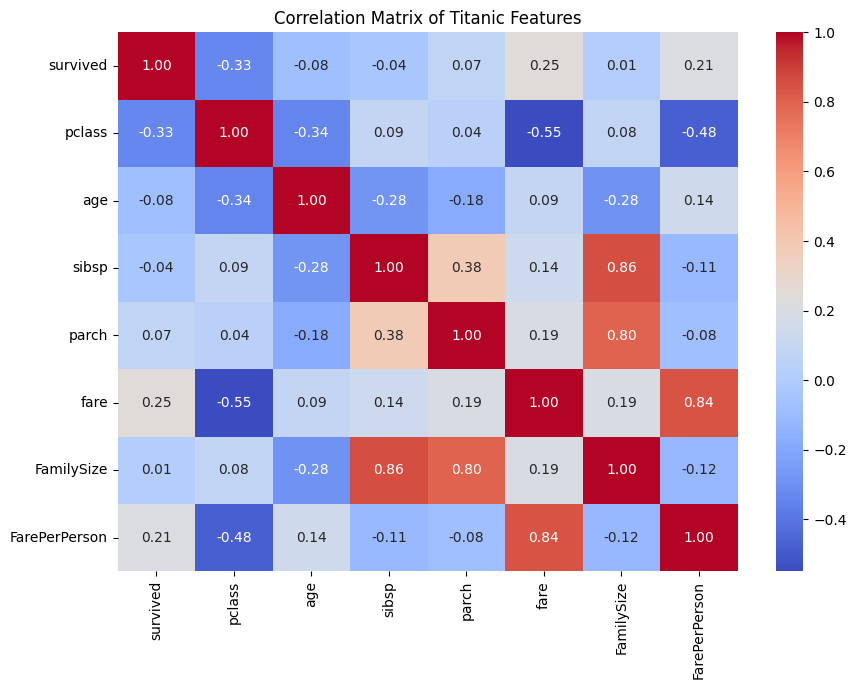

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Titanic Features"
)

plt.show()

- Answer

FamilySize is highly related to SibSp and Parch because it is directly constructed from these two features. Therefore, using FamilySize together with both SibSp and Parch may introduce redundant information. Based on the feature-selection results, some of these variables can be removed.

In [25]:
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked",
    "alone",
    "FamilySize",
    "FarePerPerson"
]

X = df_clean[features].copy()

y = df_clean["survived"]

In [26]:
X = pd.get_dummies(
    X,
    columns=["sex", "embarked"],
    drop_first=True
)

print(X.head())
print(X.columns)

   pclass   age  sibsp  parch     fare  alone  FamilySize  FarePerPerson  \
0       3  22.0      1      0   7.2500  False           2        3.62500   
1       1  38.0      1      0  71.2833  False           2       35.64165   
2       3  26.0      0      0   7.9250   True           1        7.92500   
3       1  35.0      1      0  53.1000  False           2       26.55000   
4       3  35.0      0      0   8.0500   True           1        8.05000   

   sex_male  embarked_Q  embarked_S  
0      True       False        True  
1     False       False       False  
2     False       False        True  
3     False       False        True  
4      True       False        True  
Index(['pclass', 'age', 'sibsp', 'parch', 'fare', 'alone', 'FamilySize',
       'FarePerPerson', 'sex_male', 'embarked_Q', 'embarked_S'],
      dtype='object')


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
X_train = X_train.fillna(
    X_train.median(numeric_only=True)
)

X_test = X_test.fillna(
    X_train.median(numeric_only=True)
)

In [29]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000
)

sfs = SequentialFeatureSelector(
    logistic_model,
    direction="forward",
    scoring="accuracy",
    cv=5,
    n_features_to_select="auto",
    n_jobs=-1
)

sfs.fit(
    X_train,
    y_train
)

selected_features = X_train.columns[
    sfs.get_support()
]

print(
    "Selected Features:"
)

print(
    list(selected_features)
)

Selected Features:
['pclass', 'age', 'FamilySize', 'FarePerPerson', 'sex_male']


In [30]:
print(
    "Number of selected features:",
    len(selected_features)
)

Number of selected features: 5


B3(b) — Were all features selected?

Answer

No, not necessarily. Forward Feature Selection attempts to identify a

---

useful subset of features rather than automatically selecting every available feature. Features that do not provide sufficient improvement in model performance may be excluded.

B3(c) — Compare with correlation and Random Forest

Answer

The features selected by Forward Feature Selection should be compared with the correlation matrix and Random Forest feature importance. If a feature is selected by Forward Selection and also has a strong relationship with the target or high Random Forest importance, there is stronger evidence that the feature is useful. Differences can occur because the three methods evaluate feature usefulness differently.

In [31]:
#Accuracy

logistic_model.fit(
    X_train[selected_features],
    y_train
)

y_pred = logistic_model.predict(
    X_test[selected_features]
)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy after feature selection:",
    accuracy
)

Accuracy after feature selection: 0.802547770700637


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

          Feature  Importance
1             age    0.265911
8        sex_male    0.204809
7   FarePerPerson    0.174079
4            fare    0.169668
0          pclass    0.069351
6      FamilySize    0.035574
2           sibsp    0.026412
3           parch    0.019611
10     embarked_S    0.017372
5           alone    0.010137
9      embarked_Q    0.007077


In [33]:
highest = feature_importance.iloc[0]

print(
    "Highest importance feature:"
)

print(highest)

Highest importance feature:
Feature            age
Importance    0.265911
Name: 1, dtype: object


In [34]:
lowest = feature_importance.iloc[-1]

print(
    "Lowest importance feature:"
)

print(lowest)

Lowest importance feature:
Feature       embarked_Q
Importance      0.007077
Name: 9, dtype: object


B4(c) — Compare with correlation
Answer

The Random Forest and correlation results may overlap for important features, but they are not expected to be identical. Correlation measures a statistical relationship between variables, mainly a linear relationship, whereas Random Forest importance evaluates how useful a feature is when constructing decision trees. Therefore, Random Forest can identify useful nonlinear relationships that correlation may not show.

---

5. Based on the results obtained from:

- Manual feature selection
- Correlation analysis (Filter Method)
- Random Forest feature importance (Embedded Method)
- Forward Feature Selection (Wrapper Method)
Select the final set of features that you would use to build the machine
learning model. Justify your selection.

I would select features that are supported by multiple feature-selection methods. Features such as Pclass, Sex, Age and Fare are strong candidates because they provide meaningful information about survival and are likely to be identified by more than one method. I would avoid redundant features and features that provide very little predictive value. This produces a simpler and more interpretable machine-learning dataset.

In [35]:
pca_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "FamilySize",
    "FarePerPerson"
]

In [36]:
X_pca = df_clean[
    pca_features
].copy()

print(
    "Original PCA features:"
)

print(
    X_pca.columns
)

Original PCA features:
Index(['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize',
       'FarePerPerson'],
      dtype='object')


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_pca
)

print(
    X_scaled[:5]
)

[[ 0.88515843 -0.55735956  0.4840095  -0.4971569  -0.52682497  0.04037179
  -0.46780831]
 [-1.45536167  0.60829759  0.4840095  -0.4971569   0.70158743  0.04037179
   0.37881281]
 [ 0.88515843 -0.26594527 -0.53059865 -0.4971569  -0.5138758  -0.61903406
  -0.35410276]
 [-1.45536167  0.38973687  0.4840095  -0.4971569   0.35275969  0.04037179
   0.13840093]
 [ 0.88515843  0.38973687 -0.53059865 -0.4971569  -0.5114778  -0.61903406
  -0.35079737]]


Why is feature scaling important before
performing PCA?

Answer -

PCA is based on variance. If features have different scales, features with larger numerical values can dominate the principal components. Standardization transforms the features to a comparable scale, with approximately zero mean and unit variance. This allows PCA to identify the underlying variation without being dominated by the original measurement units.

In [38]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca_result = pca.fit_transform(
    X_scaled
)

In [39]:
print(
    "Principal Components:"
)

print(
    pca.components_
)

Principal Components:
[[ 2.10204476e-01 -3.12435684e-01  5.06126055e-01  4.64190308e-01
  -3.07234484e-02  5.84947315e-01 -2.08457440e-01]
 [-4.64212959e-01  1.25571266e-01  1.40781694e-01  1.83081093e-01
   6.20290113e-01  1.92468480e-01  5.41845064e-01]
 [-2.77196327e-01  8.17005304e-01  4.06633968e-02  2.52413904e-01
  -2.03590605e-01  1.65638809e-01 -3.48443524e-01]
 [ 1.62246599e-01 -8.27159765e-02 -6.79620181e-01  7.04514885e-01
   5.85500130e-02 -5.31395167e-02  4.85528770e-02]
 [ 7.89334490e-01  4.60731725e-01  1.10931445e-01 -5.58654205e-02
   1.79136571e-01  4.12847914e-02  3.39788560e-01]
 [ 1.18784290e-01  1.57430364e-03 -5.94479560e-02 -1.07983121e-01
   7.33027350e-01 -9.81907258e-02 -6.50940001e-01]
 [ 5.18377551e-17  1.43439963e-16 -4.94610941e-01 -4.19730115e-01
  -1.09894295e-15  7.61043131e-01  1.14061893e-15]]


In [40]:
print(
    "Explained Variance Ratio:"
)

print(
    pca.explained_variance_ratio_
)

Explained Variance Ratio:
[0.36990799 0.33042881 0.12933974 0.08755752 0.06880203 0.01396391
 0.        ]


In [41]:
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print(
    "Cumulative Explained Variance:"
)

print(
    cumulative_variance
)

Cumulative Explained Variance:
[0.36990799 0.7003368  0.82967654 0.91723406 0.98603609 1.
 1.        ]
